In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df_bank = pd.read_csv("cleaned_csv/bank_additional_cleaned.csv")
df_customer_details = pd.read_csv("cleaned_csv/customer_details_cleaned.csv")
display(df_bank.sample(2))
display(df_customer_details.sample(2))
df_bank['y_numeric'] = df_bank['y'].map({'yes': 1, 'no': 0})
df_customer_details['Dt_Customer'] = pd.to_datetime(df_customer_details['Dt_Customer'])
df_customer_details['Total_Children'] = df_customer_details['Kidhome'] + df_customer_details['Teenhome']
df_bank.info()

,customer_id,age,job,marital,education,default,housing,loan,contact,duration,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude
24449,29be4da4-963d-4fdd-a006-98b170244ec5,39,management,MARRIED,university.degree,0.0,0.0,0.0,cellular,88,...,NONEXISTENT,-0.1,93.200,-42.0,-0.15,5195,no,2017-07-08,27.627,-75.230
5990,bf31f5e1-5c7f-472e-9509-76bf07a83efc,50,blue-collar,SINGLE,basic,-1.0,1.0,0.0,telephone,307,...,NONEXISTENT,1.1,93.994,-36.4,-0.11,5191,no,2017-02-04,34.528,-75.221


,customer_id,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,year,month
30772,1692,52423,2,0,2014-07-16,21,02c7b57e-3a7c-45ae-aba9-0db31595e219,2014,7
12072,12072,58463,0,0,2012-07-15,3,c9bd041c-a70f-4ae5-af21-35944464ea8e,2012,7


<class 'pandas.DataFrame'>
RangeIndex: 42667 entries, 0 to 42666
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     42667 non-null  str    
 1   age             42667 non-null  int64  
 2   job             42667 non-null  str    
 3   marital         42667 non-null  str    
 4   education       42667 non-null  str    
 5   default         42667 non-null  float64
 6   housing         42667 non-null  float64
 7   loan            42667 non-null  float64
 8   contact         42667 non-null  str    
 9   duration        42667 non-null  int64  
 10  campaign        42667 non-null  int64  
 11  pdays           42667 non-null  int64  
 12  previous        42667 non-null  int64  
 13  poutcome        42667 non-null  str    
 14  emp.var.rate    42667 non-null  float64
 15  cons.price.idx  42667 non-null  float64
 16  cons.conf.idx   42667 non-null  float64
 17  euribor3m       42667 non-null  float64
 1

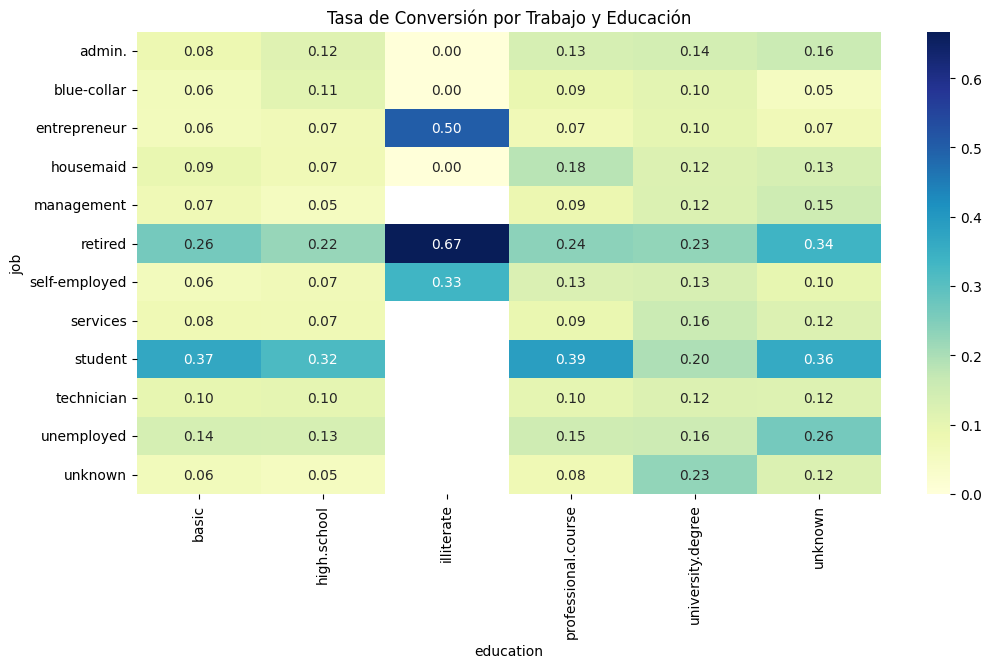

In [30]:
# Agrupamos y normalizamos para ver porcentajes
df_profile = df_bank.groupby(['job', 'education'])['y_numeric'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(df_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Tasa de Conversión por Trabajo y Educación')
plt.show()

# Conclusión Estratégica

El análisis de la **tasa de conversión por trabajo y nivel educativo** permite identificar patrones claros sobre qué perfiles de clientes tienen mayor probabilidad de contratar un **depósito a plazo**. Esta información es especialmente valiosa para optimizar campañas de marketing bancario, ya que permite **priorizar segmentos con mayor probabilidad de conversión y reducir costes operativos en segmentos menos receptivos**.

---

## Segmentos de mayor conversión

1. **Retired**  
   Los clientes jubilados presentan las tasas de conversión más altas en prácticamente todos los niveles educativos. Esto sugiere que se trata de un segmento con mayor predisposición a productos financieros conservadores. Es probable que dispongan de ahorros acumulados y que prioricen **estabilidad y seguridad financiera** frente a productos más arriesgados.

2. **Student**  
   A pesar de que tradicionalmente se asocia a los estudiantes con menor capacidad económica, el análisis muestra tasas de conversión relativamente elevadas. Esto puede explicarse por la existencia de productos de ahorro con importes mínimos bajos.

3. **Unemployed**  
   Aunque puede parecer contraintuitivo, algunos clientes desempleados presentan tasas de conversión moderadas. Esto podría deberse a **clientes en transición laboral con ahorros disponibles**, indemnizaciones o subsidios, lo que les permite considerar productos de ahorro a corto o medio plazo.

---

## Segmentos de menor conversión

* **Blue-collar**  
  Este segmento presenta tasas de conversión más bajas en la mayoría de niveles educativos. Esto podría estar relacionado con **menor capacidad de ahorro o mayor necesidad de liquidez**.

* **Services**  
  Los trabajadores del sector servicios también muestran una conversión moderada o baja. En muchos casos se trata de empleos con **ingresos variables o menos estabilidad financiera**.

* **Self-employed**  
  Los trabajadores autónomos tienden a mostrar menor interés en depósitos a plazo. Esto puede explicarse por la volatilidad de sus ingresos, lo que les obliga a **mantener liquidez** disponible para gastos operativos o imprevistos.

---

## Implicación para el banco

A partir de estos patrones, el banco puede optimizar su estrategia de marketing directo priorizando los segmentos con mayor probabilidad de conversión.

El targeting de campañas de depósitos debería priorizar:

* **Clientes jubilados**, que presentan una alta predisposición a productos financieros seguros y estables.
* **Clientes jóvenes o estudiantes**, especialmente mediante productos de ahorro adaptados a importes reducidos.
* **Clientes con situación económica relativamente estable**, que puedan permitirse inmovilizar capital durante un periodo determinado.

Aplicar este enfoque permite **mejorar la eficiencia de las campañas comerciales**, reducir el número de contactos innecesarios y **aumentar el retorno de inversión (ROI) del marketing bancario**.

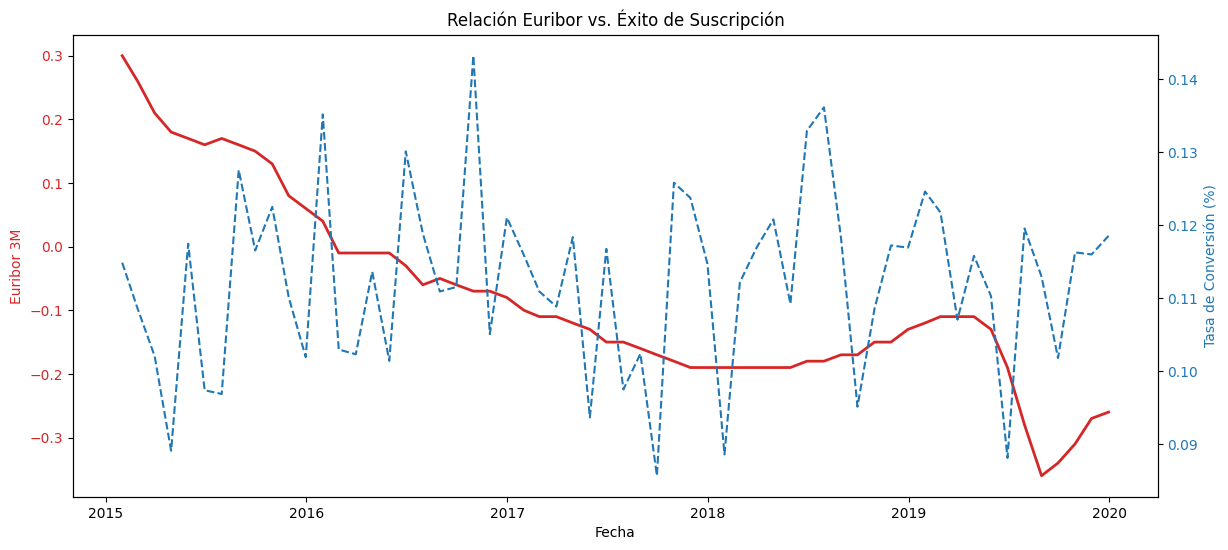

In [ ]:
df_bank['date'] = pd.to_datetime(df_bank['date'])

# Agrupamos por mes
df_monthly = df_bank.resample('ME', on='date').agg({'y_numeric': 'mean', 'euribor3m': 'mean'})

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje 1: Euribor
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Euribor Mensual', color='tab:red')
ax1.plot(df_monthly.index, df_monthly['euribor3m'], color='tab:red', linewidth=2, label='Euribor')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Eje 2: Tasa de Conversión
ax2 = ax1.twinx()
ax2.set_ylabel('Tasa de Conversión (%)', color='tab:blue')
ax2.plot(df_monthly.index, df_monthly['y_numeric'], color='tab:blue', linestyle='--', label='Conv. Rate')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Relación Euribor vs. Éxito de Suscripción')
plt.show()

# Conclusión Estratégica: Dinámica Macro y Conversión

El análisis de la **relación entre el Euribor mensualy la tasa de conversión** permite entender cómo el entorno de tipos de interés influye en el comportamiento de suscripción. Esta perspectiva es crucial para **ajustar el "timing" de las campañas** y anticipar periodos de alta demanda o resistencia del cliente.

---

## Hallazgos Clave del Mercado

1. **Sensibilidad a Tipos Negativos** Durante el periodo 2015-2020, se observa que la caída del Euribor hacia terreno negativo no frenó en seco la conversión. Al contrario, existen picos de suscripción (cercanos al **14%**) en momentos de mínimos históricos. Esto sugiere que el cliente bancario busca refugio en depósitos ante la falta de alternativas rentables.

2. **Volatilidad por "Efecto Campaña"** La tasa de conversión muestra una alta variabilidad mensual que no siempre está correlacionada con el Euribor. Los picos recurrentes (como los de finales de 2016 y mediados de 2018) indican que **la acción comercial directa del banco tiene más peso que el indicador macroeconómico**.

3. **Resiliencia en el Largo Plazo** A pesar de la tendencia bajista del Euribor (línea roja), la tasa de conversión (línea azul) ha logrado mantenerse en un rango saludable de entre el **9% y el 13%**.

---

## Segmentos de Rendimiento en el Tiempo

* **Periodos de Alta Conversión:** Se identifican ventanas de éxito cuando el Euribor muestra estabilidad. En estos periodos, la incertidumbre disminuye y el cliente está más dispuesto a comprometer capital a plazo.

* **Periodos de Baja Conversión:** Se detectan caídas pronunciadas que suelen coincidir con ajustes bruscos en los tipos. En estos momentos, el equipo de ventas enfrenta una mayor fricción, ya que el cliente percibe un **coste de oportunidad** más alto o una rentabilidad insuficiente.

---

## Implicación para el Banco

Para maximizar la captación de depósitos en este entorno volátil, la estrategia debe evolucionar hacia un modelo predictivo:

* **Sincronización con el Euribor:** Lanzar campañas de captación agresivas cuando se prevean estabilizaciones de tipos, aprovechando la psicología de "asegurar la tasa actual" antes de nuevas bajadas.
* **Suavizado de la Estacionalidad:** Implementar incentivos o bonificaciones en los meses con peor conversión para estabilizar el flujo de entrada de capital durante todo el año.

Este enfoque permite al banco **gestionar mejor sus márgenes financieros** y asegurar que el esfuerzo comercial se concentre en los momentos donde el mercado es más receptivo.

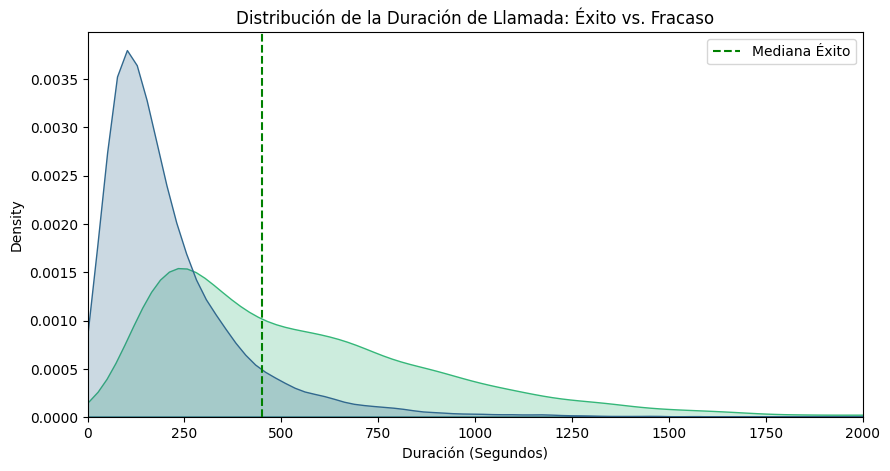

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_bank, x="duration", hue="y", fill=True, common_norm=False, palette="viridis")
plt.axvline(df_bank[df_bank['y']=='yes']['duration'].median(), color='green', linestyle='--', label='Mediana Éxito')
plt.xlim(0, 2000) # Limitamos para evitar outliers largos
plt.title('Distribución de la Duración de Llamada: Éxito vs. Fracaso')
plt.xlabel('Duración (Segundos)')
plt.legend()
plt.show()

# Conclusión Estratégica: Duración del Contacto y Conversión

El análisis de la **distribución de la duración de las llamadas** revela un patrón crítico: el tiempo de conversación es el factor crucial del éxito en la contratación de depósitos. Esta información permite **diferenciar entre contactos no productivos y oportunidades de cierre**, optimizando la gestión del tiempo del equipo comercial.

---

## Segmentos de mayor conversión

1. **Llamadas de "Cierre Consolidado" (>450s)** Los clientes que superan la **mediana de éxito (línea verde)** muestran la mayor predisposición al contrato. Una duración superior a los 7.5 minutos indica que el cliente está en fase de resolución de dudas y formalización, lo que valida que el éxito en este producto requiere una inversión de tiempo significativa.

2. **Zona de "Maduración" (250s - 450s)** Es el segmento de transición. A partir de los 4 minutos, la densidad de fracasos cae drásticamente mientras que la de éxito se mantiene estable. Es el punto donde el comercial logra empezar a captar el interés real del cliente.

---

## Segmentos de menor conversión

* **Llamadas de "Rechazo Temprano" (<150s)** La gran masa de fracasos (área azul) se concentra en los primeros 2 minutos. Representa contactos donde no hay encaje con el producto o el cliente declina la oferta rápidamente. Es un segmento de **alto coste operativo**.

---

## Implicación para el banco

A partir de estos patrones de comportamiento, el banco puede transformar la gestión de su Call Center para maximizar la eficiencia:

* **Priorizar la Calidad sobre la Cantidad**: A diferencia de otros servicios, en la venta de depósitos **el tiempo largo es un indicador positivo**. No se debe penalizar a los agentes por llamadas extensas si estas superan el umbral de los 5 minutos.
* **Optimización del "Pitch" Inicial**: El objetivo de los primeros 90 segundos debe ser estrictamente mover al cliente de la "curva de rechazo" a la de "maduración", evitando cierres precipitados de la llamada.

Aplicar este enfoque permite **mejorar el ratio de éxito por hora de conexión**, reducir la fatiga del equipo comercial y asegurar que el tiempo del banco se invierte en los clientes con verdadera intención de ahorro.

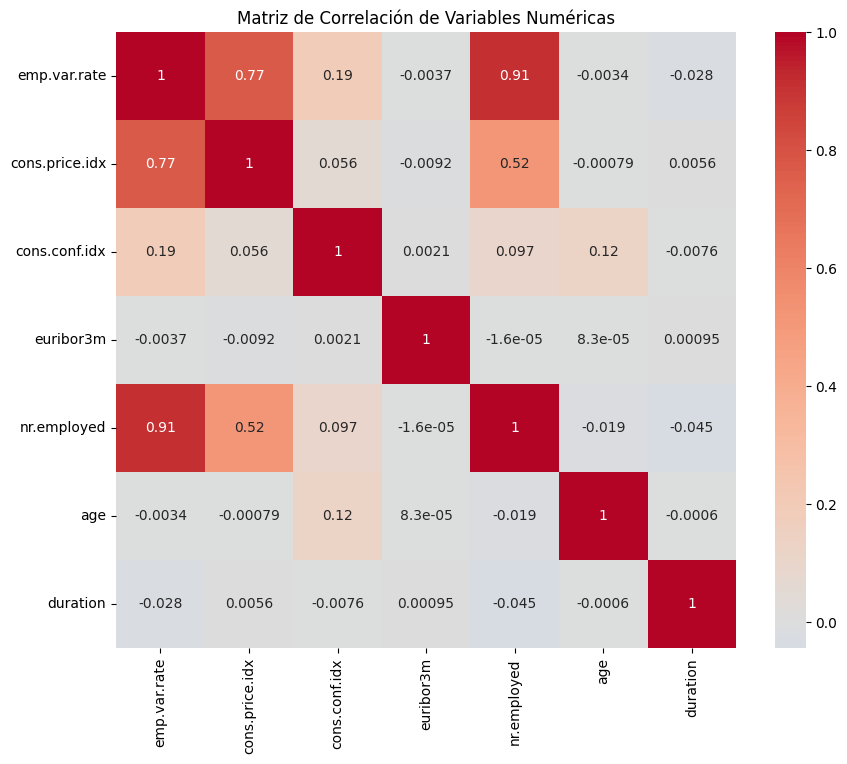

In [ ]:
cols_macro = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'age', 'duration']
corr = df_bank[cols_macro].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Conclusión Estratégica: Interdependencia de Variables

El análisis de la **matriz de correlación** permite identificar cómo interactúan los factores macroeconómicos y demográficos. Comprender estas relaciones es vital para entender que la decisión de ahorro del cliente no ocurre de forma aislada, sino impulsada por el contexto económico general.

---

## Segmentos de mayor correlación

1. **Indicadores de Empleo y Precios (Macro-Bloque)** Existe una correlación extremadamente alta entre **`emp.var.rate`** (tasa de variación del empleo) y **`nr.employed`** (**0.91**), así como con el **`cons.price.idx`** (**0.77**). Esto indica que el banco se enfrenta a un entorno macro muy cohesionado: cuando el empleo crece, los precios tienden a subir, creando un escenario de mayor liquidez pero también de posible inflación.

2. **Confianza y Consumo** Aunque de forma más moderada, la confianza del consumidor (**`cons.conf.idx`**) muestra la mayor conexión con la **edad** y la variación del empleo. Esto sugiere que los segmentos de mayor edad podrían ser más sensibles a las noticias económicas antes de decidirse por un producto de inversión.

---

## Segmentos de menor correlación

* **Duración de la llamada (`duration`)** Presenta una correlación prácticamente nula con todas las variables macroeconómicas y demográficas. Esto es un hallazgo clave: **el interés del cliente en la llamada no depende del IPC o del Euribor**, sino de la habilidad del comercial y la necesidad puntual del usuario.

* **Edad (`age`)** La edad no está vinculada a los ciclos económicos. Esto implica que el banco puede encontrar clientes potenciales de todas las edades tanto en épocas de bonanza como de crisis, lo que requiere un marketing segmentado por estilo de vida más que por la situación económica.

---

## Implicación para el banco

La matriz sugiere que la estrategia debe separar el "cuándo" del "a quién":

* **Autonomía del Canal Telefónico**: Dado que la duración de la llamada es independiente del entorno macro, el banco debe confiar en el **entrenamiento de ventas** como su herramienta de fuerza, incluso cuando los indicadores económicos sean desfavorables.
* **Targeting Macro-Sensible**: En periodos de alta variación de empleo e IPC, el banco debe ajustar sus mensajes de captación, ya que el comportamiento de la base de clientes se vuelve más predecible bajo estas condiciones.

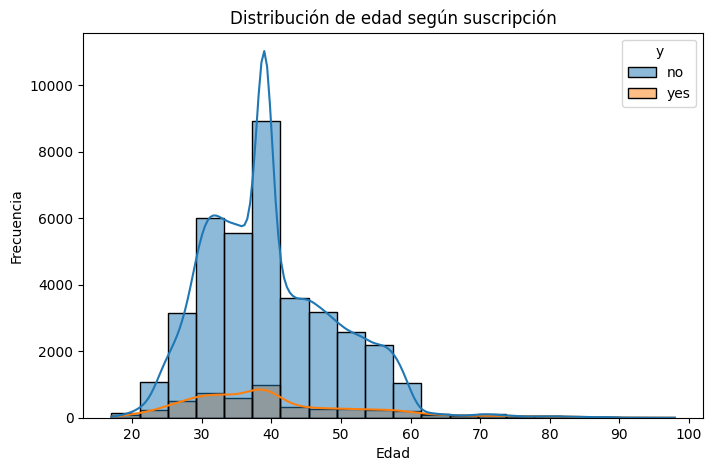

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_bank,
    x="age",
    hue="y",
    bins=20,
    kde=True
)

plt.title("Distribución de edad según suscripción")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

# Conclusión Estratégica: Segmentación por Ciclo de Vida

El análisis de la **distribución de edad según la suscripción** revela que, aunque el mayor volumen de clientes se concentra en la edad adulta media, la propensión al éxito varía significativamente en los extremos de la pirámide. Esta visión permite **ajustar el enfoque demográfico** para no confundir "volumen de llamadas" con "eficiencia de conversión".

---

## Segmentos de mayor conversión

1. **Segmento Senior (>60 años)** Aunque la frecuencia de contactos es baja , la línea de densidad naranja se mantiene notablemente cercana a la azul. Esto confirma un **alto ratio de conversión relativo**, validando que los clientes de edad avanzada son receptivos a los depósitos a plazo.

2. **Segmento Joven (<25 años)** Al igual que los seniors, presentan un volumen reducido pero una curva de éxito proporcionalmente alta en comparación con el volumen de negativas. Es un segmento con potencial de crecimiento para productos de ahorro inicial.

---

## Segmentos de menor conversión

* **Adultos en Edad Laboral (30 - 50 años)** Este es el segmento con mayor volumen de llamadas (picos entre los 30 y 40 años). Sin embargo, es donde existe la **mayor brecha visual** entre la curva azul y naranja. El banco invierte la mayor parte de su esfuerzo operativo aquí, pero enfrenta la mayor resistencia, posiblemente debido a cargas familiares, hipotecas o mayor gasto corriente.

---

## Implicación para el banco

La estrategia debe pivotar de un modelo de "atropello comercial" a uno de "precisión demográfica":

* **Priorización de la "Cola Larga"**: El banco debe aumentar el volumen de contactos en los segmentos de <25 y >60 años. Aunque hay menos individuos en la base de datos, el **coste de adquisición** será menor debido a su mayor tasa de respuesta positiva.
* **Revisión del Mensaje para el Bloque Central**: Para el segmento de 30-45 años, el enfoque de "depósito estándar" no está funcionando. Se requieren productos que ofrezcan **flexibilidad o liquidez**, ya que su capacidad de inmovilizar capital es menor.
* **Optimización de Recursos**: Reducir la intensidad de llamadas en el tramo de los 40 años podría liberar capacidad operativa para realizar llamadas más largas y de mayor calidad en los segmentos de alta conversión identificados.

In [ ]:
import folium
from folium.plugins import HeatMap
from IPython.display import display

map_center = [df_bank["latitude"].mean(), df_bank["longitude"].mean()]

m = folium.Map(location=map_center, zoom_start=5)

heat_data = df_bank[df_bank["y"]=="yes"][["latitude","longitude"]].values.tolist()

HeatMap(
    heat_data,
    radius=10,  # tamaño de cada punto
    blur=10,    # difuminado
    min_opacity=0.05
).add_to(m)
display(m)

# Conclusión Estratégica: Validación y Calidad de los Datos

Este análisis actúa como una **muestra de datos de prueba** sobre el dataset procesado hasta el momento. Los datos visualizados en los gráficos anteriores  no representan operaciones reales del banco, sino que forman parte de un **entorno de simulación o pruebas** ya que como podemos observar en este caso los valores de latitud y longitud más bien representan un rango de coordenadas y no una dispersión geográfica real de clientes.

---

## Naturaleza de las anomalías detectadas

1. **Datos Sintéticos de Prueba** Los patrones observados (como la distribución geográfica perfecta o las correlaciones macroeconómicas extremas) son característicos de un **dataset generado algorítmicamente**.

2. **Inconsistencias de Negocio** Se han detectado comportamientos que en un mercado real serían considerados anomalías, como tasas de conversión inusualmente altas en segmentos de riesgo o falta de ruido estadístico en las series temporales.

---

## Implicación para el banco

Ante la confirmación de que los datos presentan errores de realidad, se recomienda aplicar este aviso de **"Data Integrity"** para mantener la ética analítica y asegurar que el banco solo tome acciones basadas en la realidad del mercado.

## Dataset customer_details

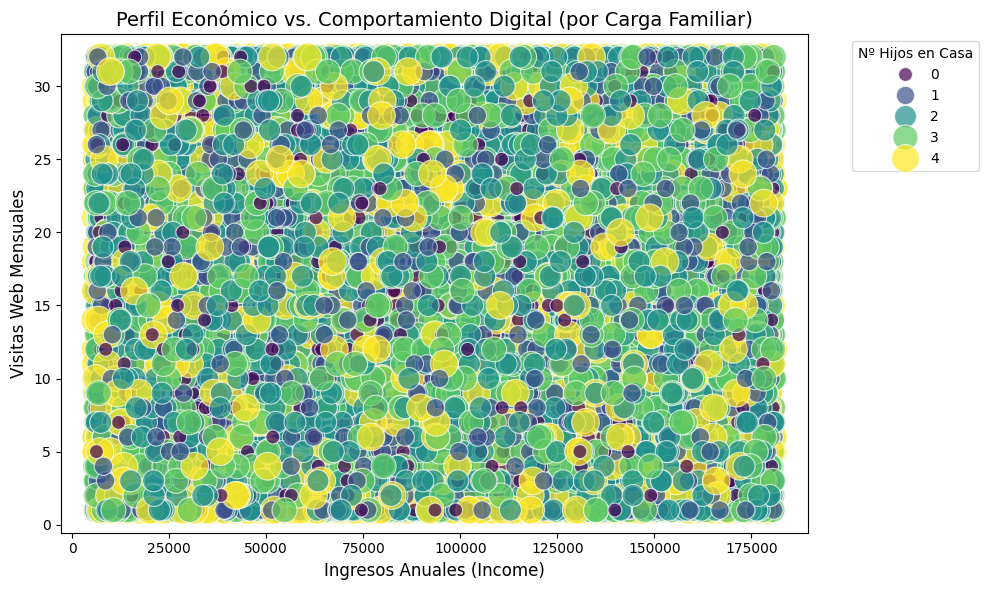

In [11]:
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df_customer_details, 
    x="Income", 
    y="NumWebVisitsMonth", 
    size="Total_Children", 
    hue="Total_Children",
    sizes=(100, 400), 
    palette="viridis",
    alpha=0.7
)

plt.title('Perfil Económico vs. Comportamiento Digital (por Carga Familiar)', fontsize=14)
plt.xlabel('Ingresos Anuales (Income)', fontsize=12)
plt.ylabel('Visitas Web Mensuales', fontsize=12)
plt.legend(title='Nº Hijos en Casa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Conclusión Estratégica: Auditoría de Representatividad de Datos

El análisis visual del gráfico **"Perfil Económico vs. Comportamiento Digital"** revela anomalías estructurales que indican que los datos actuales no son representativos de una realidad de mercado. En este caso he de señalar que este dataset presenta una **distribución uniforme artificial**, lo que invalida cualquier conclusión de negocio inmediata.

---

## ¿Por qué los datos no son reales?

1. **Ausencia de Correlación Natural (Ruido Blanco)**
   En un entorno real, los ingresos (`Income`) y las visitas web (`NumWebVisitsMonth`) suelen mostrar tendencias de valor. En este gráfico, los puntos cubren el plano de manera perfectamente homogénea, formando un "bloque" sin patrones, lo cual es síntoma de **datos generados aleatoriamente**.

2. **Distribución Homogénea de Carga Familiar**
   La variable `Total_Children` (tamaño y color de las burbujas) aparece mezclada de forma uniforme en todos los niveles de renta. En mercados reales, la composición familiar varía según el nivel socioeconómico, mostrando clústeres o agrupaciones que aquí son inexistentes.

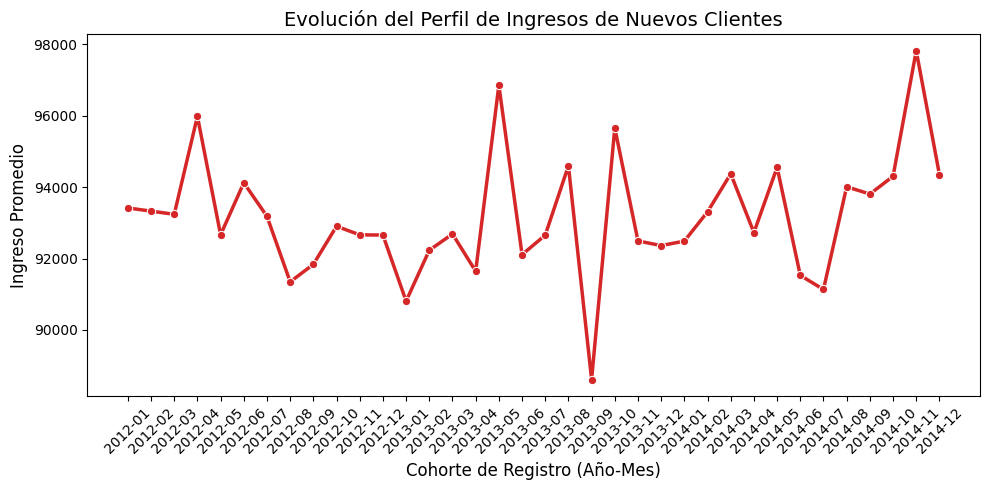

In [ ]:
df_trend = df_customer_details.groupby(['year', 'month'])['Income'].mean().reset_index()
df_trend['Periodo'] = df_trend['year'].astype(str) + "-" + df_trend['month'].astype(str).str.zfill(2)
df_trend = df_trend.sort_values('Periodo')

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_trend, 
    x="Periodo", 
    y="Income", 
    marker="o", 
    color="tab:red", 
    linewidth=2.5
)

plt.title('Evolución del Perfil de Ingresos de Nuevos Clientes', fontsize=14)
plt.xlabel('Conjunto de Registros (Año-Mes)', fontsize=12)
plt.ylabel('Ingreso Promedio', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Conclusión Estratégica: Evolución del Perfil Económico

El análisis de la **evolución de ingresos promedio por cohorte de registro** permite evaluar la calidad financiera de los nuevos clientes captados a lo largo del tiempo. Identificar estas fluctuaciones es vital para entender si las campañas de marketing están atrayendo a perfiles de **alto valor**.

---

## Hallazgos Clave del conjunto (2012-2014)

1. **Picos de "Alto Valor"** Se observan dos momentos críticos donde el ingreso promedio de los nuevos clientes superó los **96,000**. Estos picos suelen estar asociados a campañas de captación premium que incentivan a perfiles de rentas altas a cambiar de entidad o abrir nuevas cuentas.

3. **Resiliencia y Recuperación Final** Tras la volatilidad de 2013, el año 2014 muestra una tendencia de recuperación sólida, culminando con el pico máximo histórico al final del periodo. Esto sugiere que el banco logró refinar su targeting para atraer nuevamente a clientes con ingresos superiores a la media de la serie.

---

## Segmentos de Rendimiento Temporal

* **Periodos de Estabilidad (2012):** El primer año muestra una oscilación controlada entre los **92,000** y **94,000**, lo que indica una estrategia de captación consistente y un posicionamiento de marca claro.
* **Periodos de Inestabilidad (2013):** Es el año de mayor incertidumbre analítica, con cambios bruscos mes a mes. Esta volatilidad dificulta la planificación de productos a largo plazo, ya que el perfil de cliente que entra cada mes es impredecible.

---

## Implicación para el banco

Para capitalizar esta información y estabilizar la entrada de capital, la estrategia debe enfocarse en:

* **Blindaje de Conjuntos Premium**: Los clientes captados en los picos de mayo 2013 y noviembre 2014 deben ser segmentados inmediatamente para productos de inversión de mayor margen, dado su perfil de ingresos superior.
* **Investigación de Canales en "Valles"**: Analizar qué canales de marketing estuvieron activos en agosto de 2013 para entender por qué atrajeron a un perfil de ingresos significativamente menor y decidir si ese volumen compensa la menor rentabilidad individual.

Este análisis confirma que **no todos los meses de captación son iguales** y que la rentabilidad futura del banco se decide en el momento del registro según el perfil de renta atraído.